<a href="https://colab.research.google.com/github/Sriharikrishnan-TS/Portfolio_Projects/blob/main/Vision_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import numpy as np
from PIL import Image # For image loading
import matplotlib.pyplot as plt


import torch
import torchvision
from torchvision import transforms
from torch.utils.data import Dataset,DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, confusion_matrix, accuracy_score
import seaborn as sns

from transformers import ViTFeatureExtractor, ViTForImageClassification, ViTModel

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
base_image_dir = "/content/drive/MyDrive/spider_onsite/part2"

Building dataframe for rergession and classification

In [ ]:
from tqdm.notebook import tqdm
image_filenames = os.listdir(base_image_dir)
print(f"Found {len(image_filenames)} images in the dataset.")

data = []

for filename in tqdm(image_filenames, desc="Parsing filenames"):
    # Ensure it's a .jpg file
    if not filename.endswith('.jpg'):
        continue

    parts = filename.split('_')
    if len(parts) >= 4:
        try:
            age = int(parts[0])
            gender = int(parts[1])
            ethnicity = int(parts[2])


            # Store the full path to the image
            full_path = os.path.join(base_image_dir, filename)
            data.append({'filename': filename, 'filepath': full_path, 'age': age, 'gender': gender, 'ethnicity': ethnicity})
        except ValueError:
            print(f"Skipping malformed filename: {filename}")
            continue
    else:
        print(f"Skipping malformed filename (insufficient parts): {filename}")


df = pd.DataFrame(data)

Found 10729 images in the dataset.


Parsing filenames:   0%|          | 0/10729 [00:00<?, ?it/s]

Skipping malformed filename (insufficient parts): 39_1_20170116174525125.jpg
Skipping malformed filename: 53__0_20170116184028385.jpg


In [ ]:
df.tail(100)

,filename,filepath,age,gender,ethnicity
10627,23_1_0_20170112234313416.jpg,/content/drive/MyDrive/spider_onsite/part2/23_...,23,1,0
10628,23_1_0_20170112234202903.jpg,/content/drive/MyDrive/spider_onsite/part2/23_...,23,1,0
10629,23_1_0_20170112234244982.jpg,/content/drive/MyDrive/spider_onsite/part2/23_...,23,1,0
10630,23_1_0_20170112234315344.jpg,/content/drive/MyDrive/spider_onsite/part2/23_...,23,1,0
10631,23_1_0_20170112234331591.jpg,/content/drive/MyDrive/spider_onsite/part2/23_...,23,1,0
...,...,...,...,...,...
10722,31_1_1_20170112234727752.jpg,/content/drive/MyDrive/spider_onsite/part2/31_...,31,1,1
10723,34_1_1_20170112234631399.jpg,/content/drive/MyDrive/spider_onsite/part2/34_...,34,1,1
10724,32_1_1_20170112234515247.jpg,/content/drive/MyDrive/spider_onsite/part2/32_...,32,1,1
10725,35_1_1_20170112230726789.jpg,/content/drive/MyDrive/spider_onsite/part2/35_...,35,1,1


In [ ]:
X = df[['filepath','filename']]
y_age = df['age']
y_ethnicity = df['ethnicity']

X_train, X_test, y_train_age, y_test_age, y_train_ethnicity, y_test_ethnicity = train_test_split(
    X, y_age, y_ethnicity, test_size=0.2, random_state=42, stratify=y_ethnicity
)

# Create DataFrames for train and test sets
train_df = pd.DataFrame({
    'filepath': X_train['filepath'],
    'filename': X_train['filename'],
    'age': y_train_age,
    'ethnicity': y_train_ethnicity
}).reset_index(drop=True)

test_df = pd.DataFrame({
    'filepath': X_test['filepath'],
    'filename': X_test['filename'],
    'age': y_test_age,
    'ethnicity': y_test_ethnicity
}).reset_index(drop=True)

print(f"\nTraining set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")

print("\nTrain Ethnicity Distribution:")
print(train_df['ethnicity'].value_counts().sort_index())
print("\nTest Ethnicity Distribution:")
print(test_df['ethnicity'].value_counts().sort_index())


Training set size: 8581
Test set size: 2146

Train Ethnicity Distribution:
ethnicity
0    3134
1    3102
2    1455
3     448
4     442
Name: count, dtype: int64

Test Ethnicity Distribution:
ethnicity
0    784
1    775
2    364
3    112
4    111
Name: count, dtype: int64


Using transformers

In [ ]:
#  input size 224x224
model_name = 'google/vit-base-patch16-224'

# This handles resizing, normalization, and converting images to the format expected by ViT
feature_extractor = ViTFeatureExtractor.from_pretrained(model_name)


/usr/local/lib/python3.11/dist-packages/transformers/models/vit/feature_extraction_vit.py:30: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


In [ ]:
import torch
from PIL import Image
import pandas as pd

class UTKFaceDataset(Dataset):

    def __init__(self, dataframe: pd.DataFrame, feature_extractor: ViTFeatureExtractor, transform=None):

        # Store essential data as numpy arrays for faster access
        self.filepaths = dataframe['filepath'].values
        self.ages = dataframe['age'].values
        self.ethnicities = dataframe['ethnicity'].values
        self.filenames = dataframe['filename'].values

        self.feature_extractor = feature_extractor
        self.transform = transform # For additional augmentations

    def __len__(self) -> int:
        """
        Returns the total number of samples in the dataset.
        """
        return len(self.filepaths)

    def __getitem__(self, idx: int) -> dict:

        # Retrieve data directly from pre-stored arrays
        img_path = self.filepaths[idx]
        age = self.ages[idx]
        ethnicity = self.ethnicities[idx]
        filename = self.filenames[idx]

        # Load image using PIL (ViTFeatureExtractor expects PIL Image)
        image = Image.open(img_path).convert('RGB')

        # The feature_extractor returns a dictionary with 'pixel_values'
        inputs = self.feature_extractor(images=image, return_tensors="pt")
        pixel_values = inputs['pixel_values'].squeeze(0) # Remove batch dimension [1, C, H, W] -> [C, H, W]

        return {
            'pixel_values': pixel_values,
            'age': torch.tensor(float(age), dtype=torch.float32),
            'ethnicity': torch.tensor(ethnicity, dtype=torch.long),
            'filename': filename
        }

In [ ]:
augment_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5), # Randomly flip the image horizontally
    transforms.RandomRotation(degrees=10),   # Randomly rotate the image by up to 10 degrees

])


train_dataset = UTKFaceDataset(dataframe=train_df, feature_extractor=feature_extractor, transform=augment_transform)
test_dataset = UTKFaceDataset(dataframe=test_df, feature_extractor=feature_extractor, transform=None) # No augmentation for test

# Verify a sample from the dataset
sample_data = train_dataset[0]
print("\nSample data from training dataset:")
print(f"Pixel values shape: {sample_data['pixel_values'].shape}")
print(f"Age: {sample_data['age'].item()}") # .item() to get scalar value from tensor
print(f"Ethnicity: {sample_data['ethnicity'].item()}")
print(f"Pixel values type: {sample_data['pixel_values'].dtype}")
print(f"Age type: {sample_data['age'].dtype}")
print(f"Ethnicity type: {sample_data['ethnicity'].dtype}")


Sample data from training dataset:
Pixel values shape: torch.Size([3, 224, 224])
Age: 69.0
Ethnicity: 2
Pixel values type: torch.float32
Age type: torch.float32
Ethnicity type: torch.int64


In [ ]:
BATCH_SIZE = 32

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True, # Shuffle training data for better generalization
    num_workers=2 # Number of subprocesses to use for data loading.
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False, # No need to shuffle test data
    num_workers=2
)

print(f"\nNumber of training batches: {len(train_dataloader)}")
print(f"Number of test batches: {len(test_dataloader)}")

# Verify a batch from the DataLoader
for batch in train_dataloader:
    print(f"\nBatch pixel values shape: {batch['pixel_values'].shape}") # [Batch_Size, Channels, Height, Width]
    print(f"Batch age shape: {batch['age'].shape}") # [Batch_Size]
    print(f"Batch ethnicity shape: {batch['ethnicity'].shape}") # [Batch_Size]
    break # Just take one batch to inspect


Number of training batches: 269
Number of test batches: 68

Batch pixel values shape: torch.Size([32, 3, 224, 224])
Batch age shape: torch.Size([32])
Batch ethnicity shape: torch.Size([32])


In [ ]:
import torch.nn as nn

class MultiTaskViT(nn.Module):
    def __init__(self, model_name=model_name, num_ethnicity_classes=5):
        super(MultiTaskViT, self).__init__()


        self.vit = ViTModel.from_pretrained(model_name)

        self.feature_dim = self.vit.config.hidden_size

        # Regression Head for Age (continuous value)
        # A simple linear layer that maps the feature vector to a single output
        self.age_regressor = nn.Sequential(
            nn.Linear(self.feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3), # Add dropout for regularization
            nn.Linear(256, 1)
        )

        # Classification Head for Ethnicity (multi-class)
        # A linear layer that maps the feature vector to the number of ethnicity classes
        self.ethnicity_classifier = nn.Sequential(
            nn.Linear(self.feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_ethnicity_classes) # Output logits for each ethnicity class
        )

    def forward(self, pixel_values):

        vit_outputs = self.vit(pixel_values=pixel_values)

        # We take the first token (index 0) along the sequence_length dimension
        cls_token_features = vit_outputs.last_hidden_state[:, 0, :] # Shape: (batch_size, hidden_size)

        # Pass the extracted features to the age regression head
        age_prediction = self.age_regressor(cls_token_features)

        # Pass the extracted features to the ethnicity classification head
        ethnicity_prediction = self.ethnicity_classifier(cls_token_features)

        return age_prediction, ethnicity_prediction

# Instantiate the model
num_ethnicity_classes = len(df['ethnicity'].unique()) # Get this from your actual data
model = MultiTaskViT(num_ethnicity_classes=num_ethnicity_classes)

# Move the model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"\nModel instantiated and moved to {device}.")
print(model)

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Model instantiated and moved to cuda.
MultiTaskViT(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=T

In [ ]:
import torch.amp as amp
age_criterion = nn.L1Loss()
ethnicity_criterion = nn.CrossEntropyLoss()


LEARNING_RATE = 1e-5
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

scaler = amp.GradScaler()

print("\nLoss functions and optimizer defined.")


Loss functions and optimizer defined.


defining training and testing models


In [ ]:
import torch.cuda.amp # Keep this import consistent
from tqdm.notebook import tqdm
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, accuracy_score, confusion_matrix
import numpy as np

# Helper function to move a dictionary of tensors to the device
def to_device(data, device):
    if isinstance(data, dict):
        # Iterate through items, only move tensors to the device
        return {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in data.items()}
    # If the input 'data' itself is a tensor, move it
    return data.to(device) if isinstance(data, torch.Tensor) else data

def train_epoch(model, dataloader, age_criterion, ethnicity_criterion, optimizer, device,
                age_loss_weight=1.0, ethnicity_loss_weight=1.0, scaler=None):
    model.train()
    total_loss = 0.0
    total_age_loss = 0.0
    total_ethnicity_loss = 0.0

    for batch_idx, batch in enumerate(tqdm(dataloader, desc="Training")):
        # Move batch to device
        batch = to_device(batch, device)
        pixel_values = batch['pixel_values']
        true_age = batch['age']
        true_ethnicity = batch['ethnicity']

        optimizer.zero_grad() # Clear gradients


        with torch.cuda.amp.autocast()
            pred_age, pred_ethnicity = model(pixel_values)

            loss_age = age_criterion(pred_age.squeeze(1), true_age)
            loss_ethnicity = ethnicity_criterion(pred_ethnicity, true_ethnicity)

            combined_loss = (age_loss_weight * loss_age) + (ethnicity_loss_weight * loss_ethnicity)

        if scaler is not None:
            scaler.scale(combined_loss).backward()
        else:
            combined_loss.backward()

        if scaler is not None:
            scaler.step(optimizer)
            scaler.update()
        else:
            optimizer.step()


        total_loss += combined_loss.item()
        total_age_loss += loss_age.item()
        total_ethnicity_loss += loss_ethnicity.item()

    avg_loss = total_loss / len(dataloader)
    avg_age_loss = total_age_loss / len(dataloader)
    avg_ethnicity_loss = total_ethnicity_loss / len(dataloader)

    return avg_loss, avg_age_loss, avg_ethnicity_loss


def evaluate_model(model, dataloader, age_criterion, ethnicity_criterion, device):
    model.eval()
    total_loss = 0.0
    total_age_loss = 0.0
    total_ethnicity_loss = 0.0

    all_pred_ages = []
    all_true_ages = []
    all_pred_ethnicities = []
    all_true_ethnicities = []

    with torch.no_grad(): # Disable gradient calculations for evaluation
        for batch_idx, batch in enumerate(tqdm(dataloader, desc="Evaluating")):
            # Move batch to device
            batch = to_device(batch, device)
            pixel_values = batch['pixel_values']
            true_age = batch['age']
            true_ethnicity = batch['ethnicity']


            global AGE_LOSS_WEIGHT, ETHNICITY_LOSS_WEIGHT # Access global variables

            with torch.cuda.amp.autocast():
                # Forward pass
                pred_age, pred_ethnicity = model(pixel_values)

                loss_age = age_criterion(pred_age.squeeze(1), true_age)
                loss_ethnicity = ethnicity_criterion(pred_ethnicity, true_ethnicity)

            total_loss += (AGE_LOSS_WEIGHT * loss_age.item()) + (ETHNICITY_LOSS_WEIGHT * loss_ethnicity.item())
            total_age_loss += loss_age.item()
            total_ethnicity_loss += loss_ethnicity.item()

            # Store predictions and true values for metrics calculation
            all_pred_ages.extend(pred_age.squeeze(1).cpu().numpy())
            all_true_ages.extend(true_age.cpu().numpy())
            # For classification, get the predicted class by taking argmax of logits
            all_pred_ethnicities.extend(torch.argmax(pred_ethnicity, dim=1).cpu().numpy())
            all_true_ethnicities.extend(true_ethnicity.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    avg_age_loss = total_age_loss / len(dataloader)
    avg_ethnicity_loss = total_ethnicity_loss / len(dataloader)

    # Calculate evaluation metrics
    age_mae = mean_absolute_error(all_true_ages, all_pred_ages)

    ethnicity_accuracy = accuracy_score(all_true_ethnicities, all_pred_ethnicities)
    ethnicity_conf_matrix = confusion_matrix(all_true_ethnicities, all_pred_ethnicities)

    return avg_loss, avg_age_loss, avg_ethnicity_loss, age_mae, ethnicity_accuracy, ethnicity_conf_matrix

In [ ]:
from timeit import default_timer as timer
def find_time(start,end,device):
    total_sec = end-start
    hours = total_sec // 3600
    minutes = (total_sec % 3600 ) // 60
    rem_sec = total_sec % 60

    if hours > 0:
        print(f"total training time on {device} : {int(hours)} hrs {int(minutes)} minutes {int(rem_sec)} seconds")
    else:
        print(f"total training time on {device} : {int(minutes)} minutes and {int(rem_sec)} seconds")

In [ ]:
NUM_EPOCHS = 5
AGE_LOSS_WEIGHT = 1000
ETHNICITY_LOSS_WEIGHT = 10000

# Store history for plotting
history = {
    'train_total_loss': [], 'train_age_loss': [], 'train_ethnicity_loss': [],
    'val_total_loss': [], 'val_age_loss': [], 'val_ethnicity_loss': [],
    'val_age_mae': [], 'val_ethnicity_accuracy': []
}

best_val_loss = float('inf')
epochs_no_improve = 0
PATIENCE = 3 # Number of epochs to wait for improvement before stopping

# Directory to save the best model
MODEL_SAVE_DIR = "/content/drive/MyDrive"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(MODEL_SAVE_DIR, 'best_multi_task_vit.pth')

start = timer()

print("\nStarting training...\n")
for epoch in range(NUM_EPOCHS):
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")

    # Training phase
    train_total_loss, train_age_loss, train_ethnicity_loss = train_epoch(
        model, train_dataloader, age_criterion, ethnicity_criterion, optimizer, device,
        AGE_LOSS_WEIGHT, ETHNICITY_LOSS_WEIGHT
    )
    history['train_total_loss'].append(train_total_loss)
    history['train_age_loss'].append(train_age_loss)
    history['train_ethnicity_loss'].append(train_ethnicity_loss)


    # Evaluation phase
    val_total_loss, val_age_loss, val_ethnicity_loss, val_age_mae, val_ethnicity_accuracy, _ = evaluate_model(
        model, test_dataloader, age_criterion, ethnicity_criterion, device
    )
    history['val_total_loss'].append(val_total_loss)
    history['val_age_loss'].append(val_age_loss)
    history['val_ethnicity_loss'].append(val_ethnicity_loss)
    history['val_age_mae'].append(val_age_mae)
    history['val_ethnicity_accuracy'].append(val_ethnicity_accuracy)

    print(f"  Train: Total Loss: {train_total_loss:.4f}, Age Loss: {train_age_loss:.4f}, Ethnicity Loss: {train_ethnicity_loss:.4f}")
    print(f"  Val:   Total Loss: {val_total_loss:.4f}, Age Loss: {val_age_loss:.4f}, Ethnicity Loss: {val_ethnicity_loss:.4f}")
    print(f"  Val Metrics: Age MAE: {val_age_mae:.2f}, Ethnicity Accuracy: {val_ethnicity_accuracy:.4f}")

    # Early Stopping and Model Checkpointing
    if val_total_loss < best_val_loss:
        best_val_loss = val_total_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  Validation loss improved. Saving model to {BEST_MODEL_PATH}")
    else:
        epochs_no_improve += 1
        print(f"  Validation loss did not improve for {epochs_no_improve} epochs.")
        if epochs_no_improve >= PATIENCE:
            print(f"  Early stopping triggered after {epochs_no_improve} epochs without improvement.")
            break
end = timer()
find_time(start,end,device)
print("\nTraining complete!")


Starting training...

Epoch 1/5


Training:   0%|          | 0/269 [00:00<?, ?it/s]

/tmp/ipython-input-67-840598377.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(): # This is correct for your environment


Evaluating:   0%|          | 0/68 [00:00<?, ?it/s]

/tmp/ipython-input-67-840598377.py:95: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Training:   0%|          | 0/269 [00:00<?, ?it/s]

/tmp/ipython-input-67-840598377.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(): # This is correct for your environment


Evaluating:   0%|          | 0/68 [00:00<?, ?it/s]

/tmp/ipython-input-67-840598377.py:95: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  Train: Total Loss: 10014.8311, Age Loss: 7.9904, Ethnicity Loss: 0.2024
  Val:   Total Loss: 11897.4032, Age Loss: 7.4919, Ethnicity Loss: 0.4405
  Val Metrics: Age MAE: 7.45, Ethnicity Accuracy: 0.8602
  Validation loss improved. Saving model to /content/drive/MyDrive/best_multi_task_vit.pth
total training time on cuda : 15 minutes and 11 seconds

Training complete!


In [ ]:

num_ethnicity_classes = len(df['ethnicity'].unique())
final_model = MultiTaskViT(num_ethnicity_classes=num_ethnicity_classes)


BEST_MODEL_PATH = os.path.join(MODEL_SAVE_DIR, 'best_multi_task_vit.pth')

if os.path.exists(BEST_MODEL_PATH):
    final_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
    print(f"Successfully loaded best model from {BEST_MODEL_PATH}")
else:
    print(f"Error: Best model not found at {BEST_MODEL_PATH}. Using the last trained model state.")
    final_model = model

final_model.to(device) # Move the loaded model to the device
final_model.eval() # Set to evaluation mode

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Successfully loaded best model from model_checkpoints/best_multi_task_vit.pth


MultiTaskViT(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermediate_act_fn):

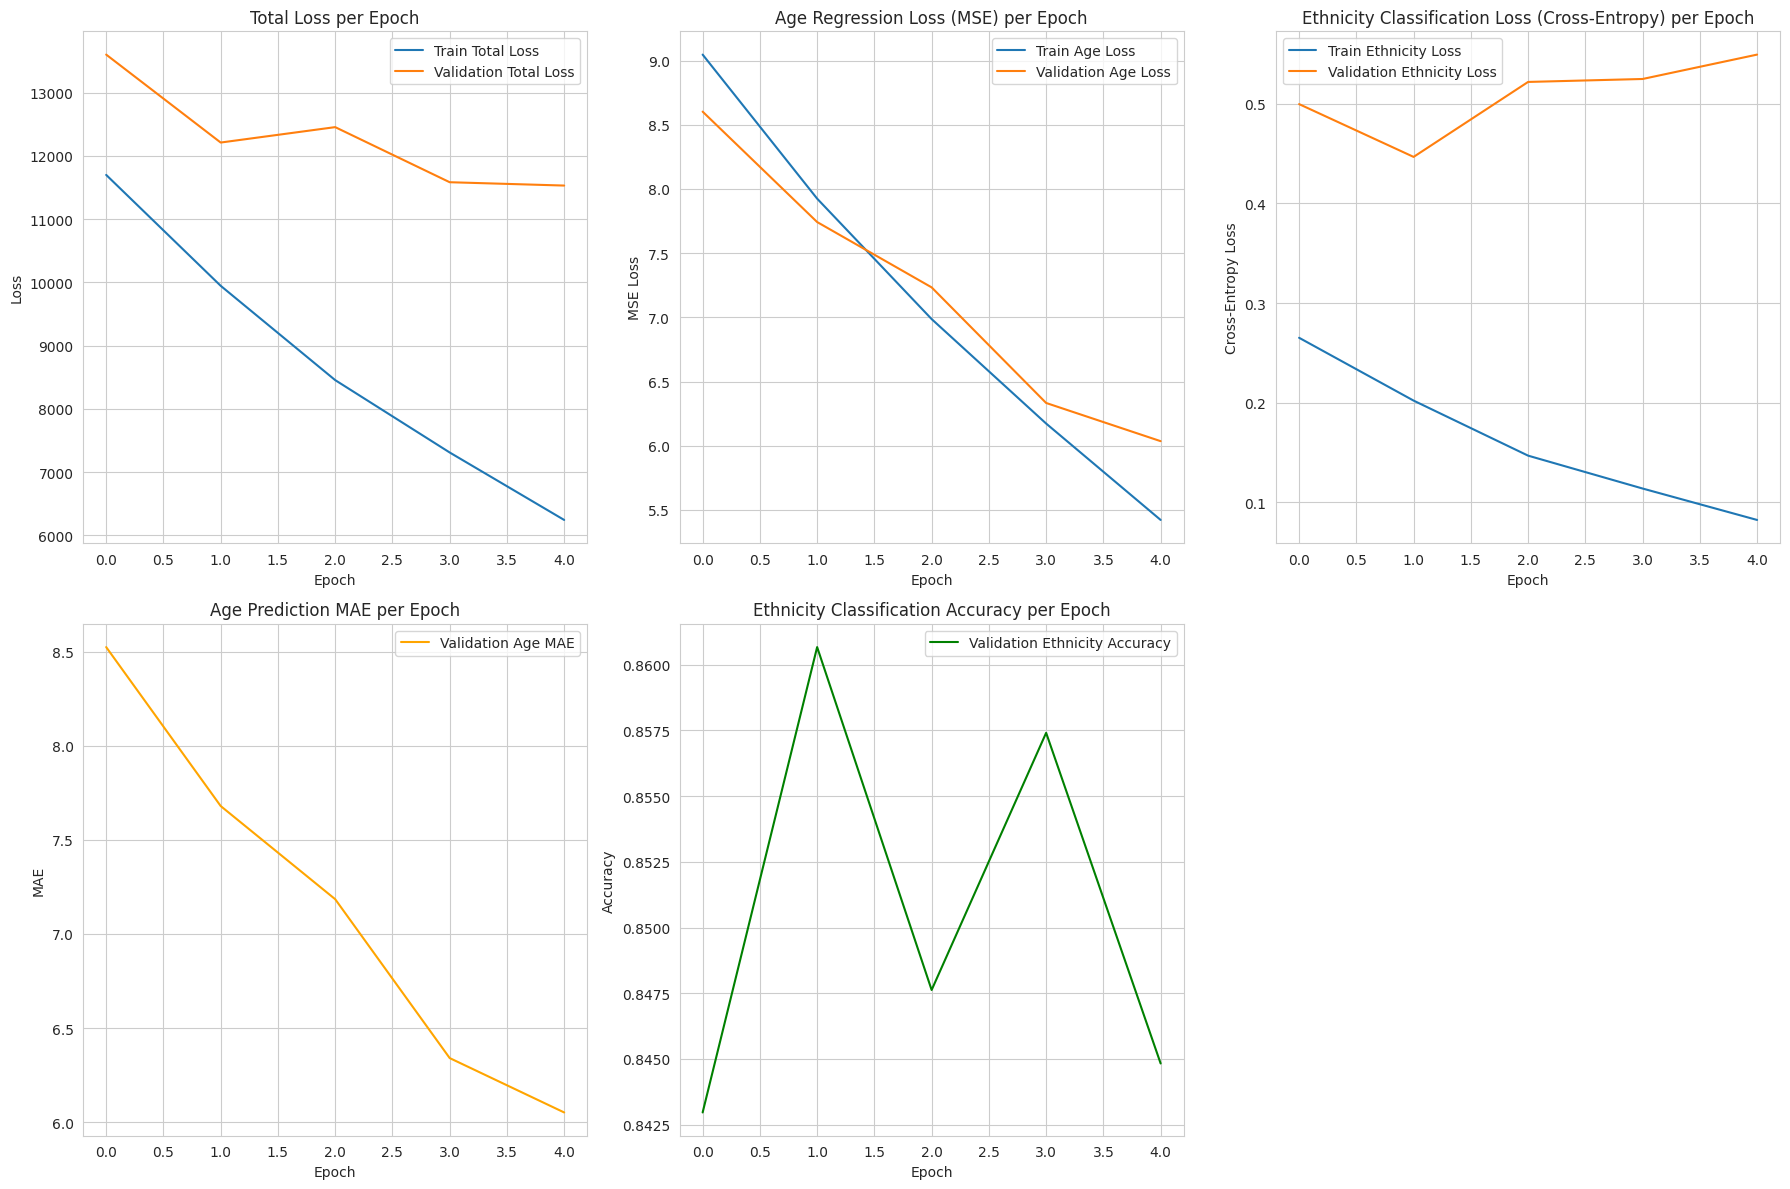


Confusion Matrix for Ethnicity (on Test Set):


Evaluating:   0%|          | 0/68 [00:00<?, ?it/s]

/tmp/ipython-input-50-1830071146.py:93: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


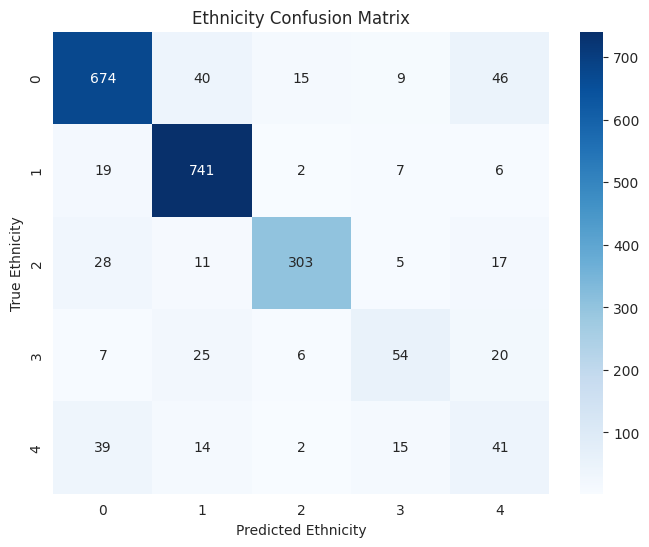

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style("whitegrid")
plt.figure(figsize=(18, 12))

# Plot Total Loss
plt.subplot(2, 3, 1)
plt.plot(history['train_total_loss'], label='Train Total Loss')
plt.plot(history['val_total_loss'], label='Validation Total Loss')
plt.title('Total Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Age Loss
plt.subplot(2, 3, 2)
plt.plot(history['train_age_loss'], label='Train Age Loss')
plt.plot(history['val_age_loss'], label='Validation Age Loss')
plt.title('Age Regression Loss (MSE) per Epoch')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()

# Plot Ethnicity Loss
plt.subplot(2, 3, 3)
plt.plot(history['train_ethnicity_loss'], label='Train Ethnicity Loss')
plt.plot(history['val_ethnicity_loss'], label='Validation Ethnicity Loss')
plt.title('Ethnicity Classification Loss (Cross-Entropy) per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()

# Plot Age MAE
plt.subplot(2, 3, 4)
plt.plot(history['val_age_mae'], label='Validation Age MAE', color='orange')
plt.title('Age Prediction MAE per Epoch')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

# Plot Ethnicity Accuracy
plt.subplot(2, 3, 5)
plt.plot(history['val_ethnicity_accuracy'], label='Validation Ethnicity Accuracy', color='green')
plt.title('Ethnicity Classification Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Plot Confusion Matrix for Ethnicity
print("\nConfusion Matrix for Ethnicity (on Test Set):")

final_val_total_loss, final_val_age_loss, final_val_ethnicity_loss, final_val_age_mae, final_val_ethnicity_accuracy, final_ethnicity_conf_matrix = evaluate_model(
    model, test_dataloader, age_criterion, ethnicity_criterion, device
)

plt.figure(figsize=(8, 6))
sns.heatmap(final_ethnicity_conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(num_ethnicity_classes), yticklabels=range(num_ethnicity_classes))
plt.xlabel('Predicted Ethnicity')
plt.ylabel('True Ethnicity')
plt.title('Ethnicity Confusion Matrix')
plt.show()

In [ ]:
# Prepare lists to store predictions and filenames
predicted_ages = []
predicted_ethnicities = []
original_filenames = []

print("\nGenerating predictions on the test set...")
with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm(test_dataloader, desc="Predicting")):
        batch = to_device(batch, device)
        pixel_values = batch['pixel_values']


        start_idx = batch_idx * test_dataloader.batch_size
        end_idx = start_idx + pixel_values.size(0) # Use actual batch size
        current_filenames = test_df['filename'].iloc[start_idx:end_idx].tolist()
        original_filenames.extend(current_filenames)

        # Forward pass
        pred_age, pred_ethnicity_logits = final_model(pixel_values)

        # Process predictions
        # Age: Convert tensor to list of floats
        predicted_ages.extend(pred_age.squeeze(1).cpu().numpy().tolist())

        # Ethnicity: Get the class with the highest probability (argmax)
        predicted_ethnicities.extend(torch.argmax(pred_ethnicity_logits, dim=1).cpu().numpy().tolist())

# Create a DataFrame for submission
submission_df = pd.DataFrame({
    'filename': original_filenames,
    'predicted_age': predicted_ages,
    'predicted_ethnicity': predicted_ethnicities
})

# Round predicted age to the nearest integer as age is an integer in the dataset
submission_df['predicted_age'] = submission_df['predicted_age'].round().astype(int)

# Ensure ethnicity is integer type
submission_df['predicted_ethnicity'] = submission_df['predicted_ethnicity'].astype(int)

# Save the DataFrame to a CSV file
submission_csv_path = '/content/drive/MyDrive/submission.csv'
submission_df.to_csv(submission_csv_path, index=False)

print(f"\nSubmission file created: {submission_csv_path}")
print("Submission DataFrame Head:")
print(submission_df.head())
print("\nSubmission DataFrame Info:")
submission_df.info()


Generating predictions on the test set...


Predicting:   0%|          | 0/68 [00:00<?, ?it/s]


Submission file created: /content/drive/MyDrive/submission.csv
Submission DataFrame Head:
                       filename  predicted_age  predicted_ethnicity
0  37_1_0_20170117172109990.jpg             35                    0
1  24_1_2_20170116172609939.jpg             25                    2
2  36_1_1_20170116223054510.jpg             35                    1
3  54_0_3_20170117191318186.jpg             33                    3
4  30_0_1_20170117130035831.jpg             27                    1

Submission DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2146 entries, 0 to 2145
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   filename             2146 non-null   object
 1   predicted_age        2146 non-null   int64 
 2   predicted_ethnicity  2146 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 50.4+ KB
